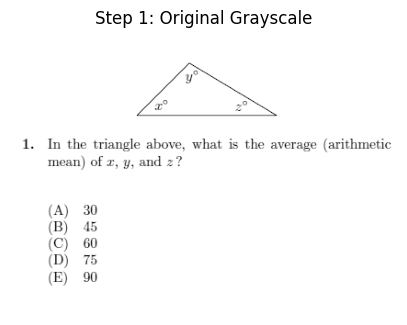

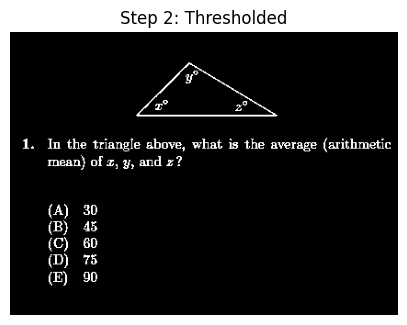

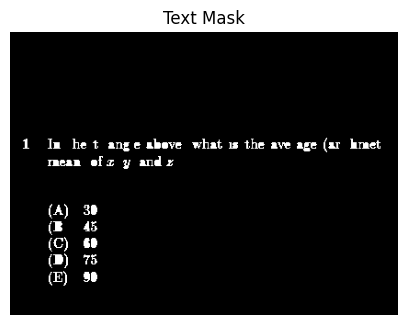

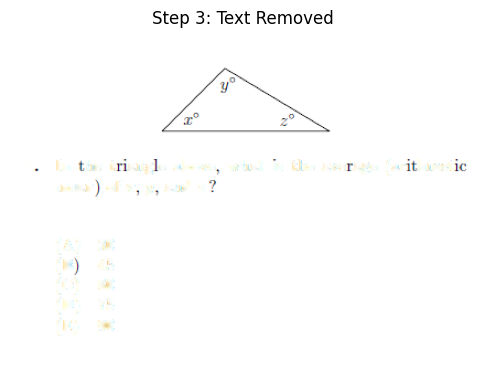

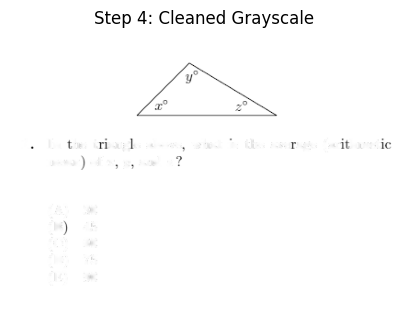

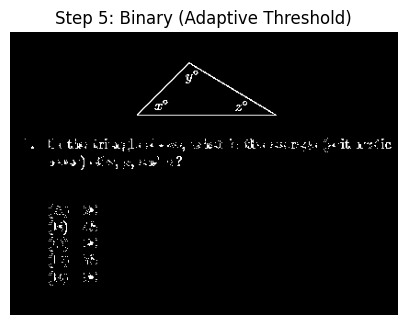

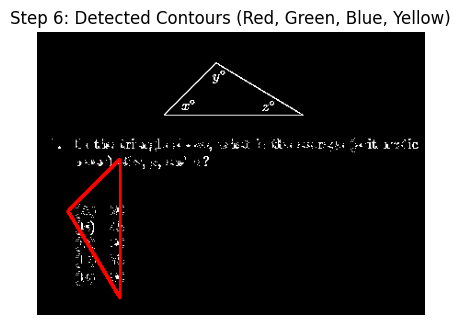

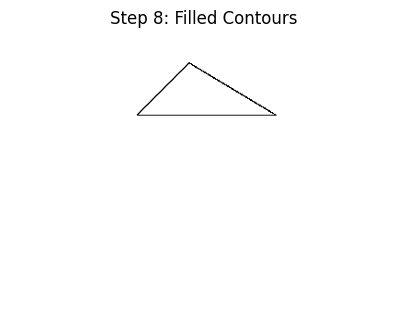

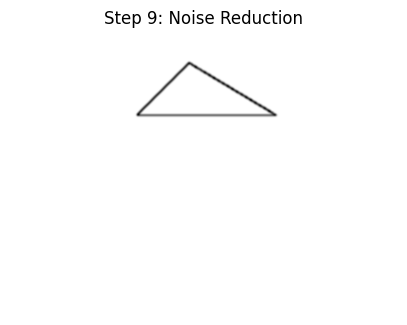

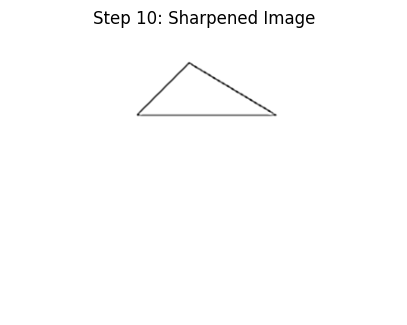

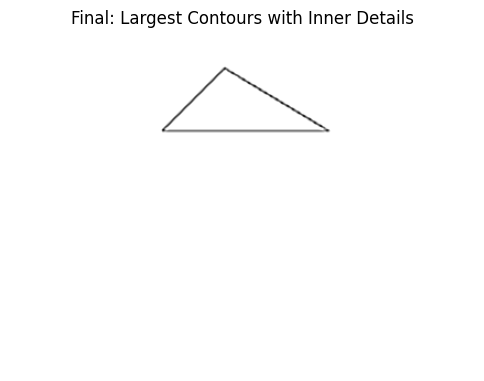

Detected Shapes: ['unknown']
Largest contour size: 430, Second largest: None


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def preprocess_image(image_path):
    # Step 1: Read and convert to grayscale
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", gray)

    # Step 2: Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY_INV, 15, 9)
    plt.figure(figsize=(5, 5))
    plt.imshow(thresh, cmap='gray')
    plt.title("Step 2: Thresholded")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_thresholded.png", thresh)

    return image, gray, thresh

def detect_text_regions(thresh):
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(thresh)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        aspect_ratio = w / float(h)

        # Filter likely text: small area and reasonable aspect ratio
        if 10 < area < 3000 and 0.2 < aspect_ratio < 10:
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    plt.figure(figsize=(5, 5))
    plt.imshow(mask, cmap='gray')
    plt.title("Text Mask")
    plt.axis("off")
    plt.show()
    cv2.imwrite("text_mask.png", mask)

    return mask

def remove_text(image, mask):
    # Inpainting to remove text
    cleaned = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
    plt.title("Step 3: Text Removed")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step3_text_removed.png", cleaned)
    return cleaned

def preprocess_for_contours(cleaned_image):
    # Convert cleaned image to grayscale
    gray = cv2.cvtColor(cleaned_image, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 4: Cleaned Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step4_cleaned_grayscale.png", gray)

    # Binary thresholding
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 5: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step5_binary.png", binary)

    return binary

def find_contours_manual(binary):
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check 8 neighbors for complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    contours.sort(key=len, reverse=True)
    return contours[:4]  # Return top 4 contours

def classify_shape(contour):
    # Convert contour list of tuples to NumPy array with correct shape (n, 1, 2)
    contour_array = np.array(contour, dtype=np.int32).reshape(-1, 1, 2)
    
    # Approximate the contour with a polygon
    epsilon = 3 * cv2.arcLength(contour_array, True)
    approx = cv2.approxPolyDP(contour_array, epsilon, True)
    vertices_count = len(approx)

    area = cv2.contourArea(contour_array)
    perimeter = cv2.arcLength(contour_array, True)
    shape = "unknown"

    if vertices_count == 3:
        shape = "triangle"
    elif vertices_count == 4:
        # Calculate side lengths and angles for square/rectangle detection
        side_lengths = [math.hypot(approx[i][0][0] - approx[(i + 1) % 4][0][0],
                                  approx[i][0][1] - approx[(i + 1) % 4][0][1]) for i in range(4)]
        angles = []
        for i in range(4):
            p0, p1, p2 = approx[i - 1][0], approx[i][0], approx[(i + 1) % 4][0]
            v1 = (p0[0] - p1[0], p0[1] - p1[1])
            v2 = (p2[0] - p1[0], p2[1] - p1[1])
            dot_prod = v1[0] * v2[0] + v1[1] * v2[1]
            mag1 = math.hypot(v1[0], v1[1])
            mag2 = math.hypot(v2[0], v2[1])
            cos_theta = dot_prod / (mag1 * mag2) if mag1 and mag2 else 0
            angle = math.acos(min(max(cos_theta, -1), 1)) * 180 / math.pi
            angles.append(angle)

        is_square = all(abs(side_lengths[i] - side_lengths[0]) < 5 for i in range(1, 4)) and all(abs(a - 90) < 10 for a in angles)
        is_rectangle = all(abs(a - 90) < 15 for a in angles)

        if is_square:
            shape = "square"
        elif is_rectangle:
            shape = "rectangle"
        else:
            shape = "quadrilateral"
    elif vertices_count > 4:
        circularity = 4 * math.pi * area / (perimeter ** 2) if perimeter != 0 else 0
        shape = "circle" if circularity > 0.8 else "polygon"

    return shape, approx

def detect_inscribed_shapes(contour_image, contours):
    inscribed_shapes = []
    for i, outer_contour in enumerate(contours):
        outer_contour_array = np.array(outer_contour, dtype=np.int32).reshape(-1, 1, 2)
        for j, inner_contour in enumerate(contours):
            if i != j:
                inner_contour_array = np.array(inner_contour, dtype=np.int32).reshape(-1, 1, 2)
                if cv2.pointPolygonTest(outer_contour_array, tuple(inner_contour_array[0][0]), False) >= 0:
                    shape, _ = classify_shape(inner_contour)
                    inscribed_shapes.append((shape, i, j))
    return inscribed_shapes

def detect_largest_contour(image_path):
    # Text removal process
    image, gray, thresh = preprocess_image(image_path)
    text_mask = detect_text_regions(thresh)
    cleaned_image = remove_text(image, text_mask)

    # Contour detection process
    binary = preprocess_for_contours(cleaned_image)

    contours = find_contours_manual(binary)
    if not contours:
        print("No contours found.")
        return

    if len(contours) < 1:
        print("No valid contours found.")
        return

    # Step 6: Visualize detected contours with color
    contour_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]  # Red, Green, Blue, Yellow
    for idx, contour in enumerate(contours):
        if idx < len(colors):
            coords = np.array(contour, dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(contour_image, [coords], isClosed=True, color=colors[idx], thickness=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_image)
    plt.title("Step 6: Detected Contours (Red, Green, Blue, Yellow)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step6_detected_contours.png", contour_image)

    # Step 7: Classify shapes
    shapes = []
    for contour in contours:
        shape, approx = classify_shape(contour)
        shapes.append((shape, contour, approx))

    # Step 8: Create and fill contours on a new canvas
    outline_image = np.ones_like(binary) * 255  # White background
    for shape, contour, _ in shapes[:2]:  # Limit to top 2 contours
        coords = np.array(contour, dtype=np.int32)
        color = 0 if shape in ["circle", "triangle"] else 128  # Black for circle/triangle, gray for others
        outline_image[coords[:, 0], coords[:, 1]] = color  # Direct assignment to original contour points
    plt.figure(figsize=(5, 5))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Step 8: Filled Contours")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step8_filled_contours.png", outline_image)

    # Step 9: Noise Reduction
    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)
    plt.figure(figsize=(5, 5))
    plt.imshow(noise_reduced, cmap='gray')
    plt.title("Step 9: Noise Reduction")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step9_noise_reduced.png", noise_reduced)

    # Step 10: Sharpen the image
    kernel = np.array([[-1, -1, -1],
                      [-1, 9, -1],
                      [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)
    plt.figure(figsize=(5, 5))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Step 10: Sharpened Image")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step10_sharpened.png", sharpened)

    # Step 11: Detect inscribed shapes
    inscribed_shapes = detect_inscribed_shapes(outline_image, contours)
    if inscribed_shapes:
        print("Inscribed Shapes Found:", [(s[0], s[1], s[2]) for s in inscribed_shapes])

    # Final output
    plt.figure(figsize=(6, 6))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Final: Largest Contours with Inner Details")
    plt.axis("off")
    plt.show()
    cv2.imwrite("final_contours.png", sharpened)

    # Print detected shapes
    print("Detected Shapes:", [s[0] for s in shapes[:2]])
    print(f"Largest contour size: {len(contours[0])}, Second largest: {len(contours[1]) if len(contours) > 1 else 'None'}")

image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\009.png"
detect_largest_contour(image_path)

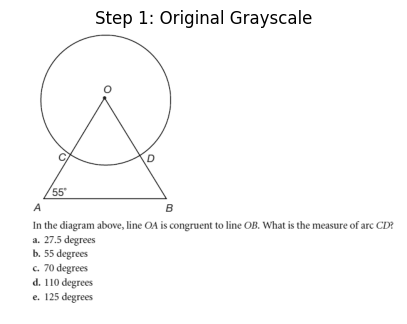

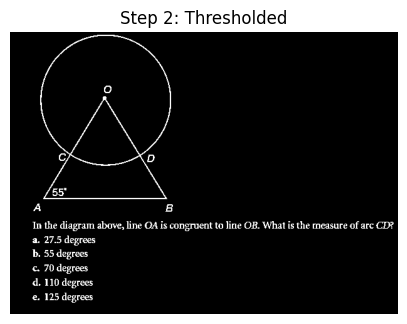

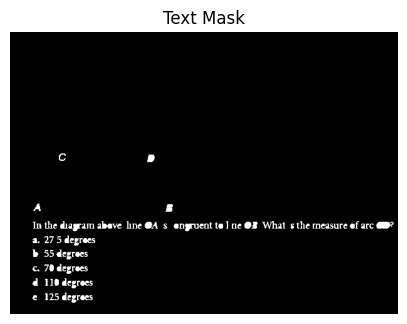

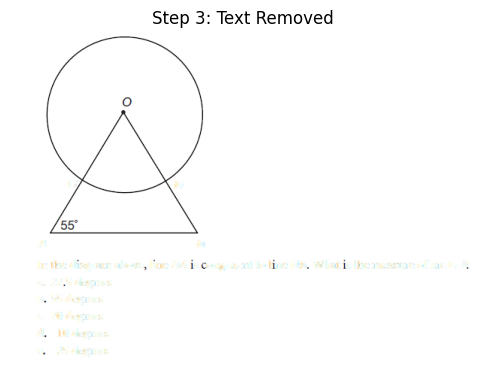

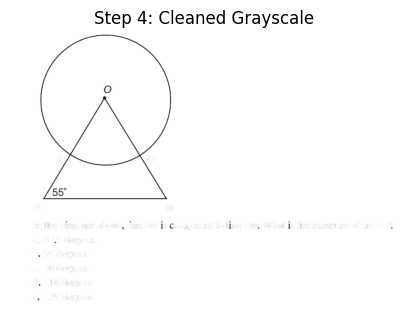

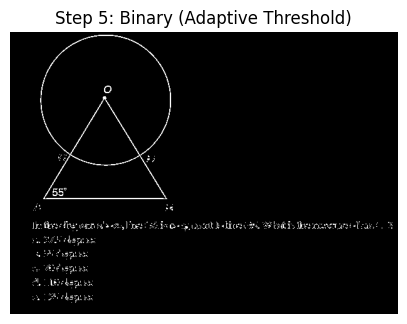

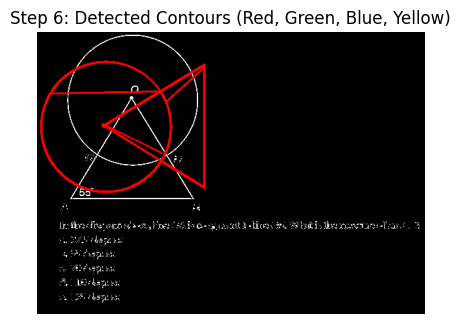

Vertices count: 21, Area: 6517.5, Perimeter: 2942.683284521103


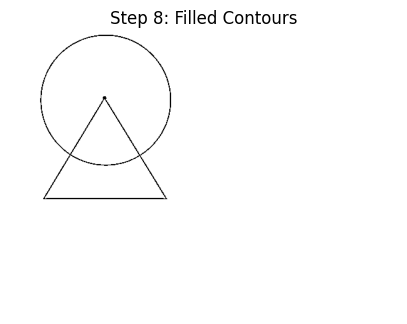

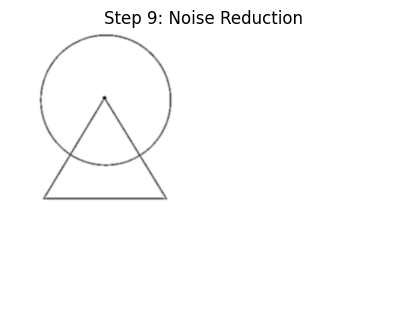

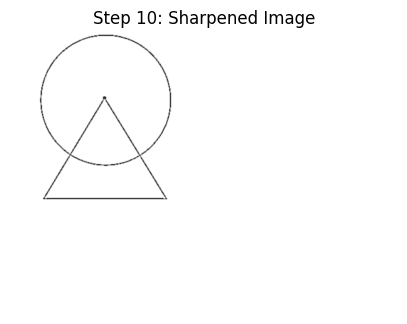

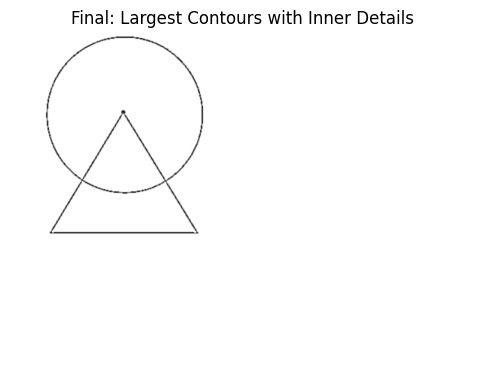

Detected Shapes: ['polygon']
Largest contour size: 2157, Second largest: None


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def preprocess_image(image_path):
    # Step 1: Read and convert to grayscale
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", gray)

    # Step 2: Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY_INV, 15, 9)
    plt.figure(figsize=(5, 5))
    plt.imshow(thresh, cmap='gray')
    plt.title("Step 2: Thresholded")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_thresholded.png", thresh)

    return image, gray, thresh

def detect_text_regions(thresh):
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(thresh)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        aspect_ratio = w / float(h)

        # Filter likely text: small area and reasonable aspect ratio
        if 10 < area < 3000 and 0.2 < aspect_ratio < 10:
            cv2.drawContours(mask, [cnt], -1, 255, -1)

    plt.figure(figsize=(5, 5))
    plt.imshow(mask, cmap='gray')
    plt.title("Text Mask")
    plt.axis("off")
    plt.show()
    cv2.imwrite("text_mask.png", mask)

    return mask

def remove_text(image, mask):
    # Inpainting to remove text
    cleaned = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(cleaned, cv2.COLOR_BGR2RGB))
    plt.title("Step 3: Text Removed")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step3_text_removed.png", cleaned)
    return cleaned

def preprocess_for_contours(cleaned_image):
    # Convert cleaned image to grayscale
    gray = cv2.cvtColor(cleaned_image, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap='gray')
    plt.title("Step 4: Cleaned Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step4_cleaned_grayscale.png", gray)

    # Binary thresholding
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 5: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step5_binary.png", binary)

    return binary

def find_contours_manual(binary):
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check 8 neighbors for complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    contours.sort(key=len, reverse=True)
    return contours[:4]  # Return top 4 contours

def classify_shape(contour):
    # Convert contour list of tuples to NumPy array with correct shape (n, 1, 2)
    contour_array = np.array(contour, dtype=np.int32).reshape(-1, 1, 2)
    
    # Approximate the contour with a polygon (use 1% of arc length for better accuracy)
    perimeter = cv2.arcLength(contour_array, True)
    epsilon = 0.01 * perimeter
    approx = cv2.approxPolyDP(contour_array, epsilon, True)
    vertices_count = len(approx)

    area = cv2.contourArea(contour_array)
    perimeter = cv2.arcLength(contour_array, True)
    shape = "unknown"

    print(f"Vertices count: {vertices_count}, Area: {area}, Perimeter: {perimeter}")  # Debug print

    if vertices_count == 3:
        shape = "triangle"
    elif vertices_count == 4:
        # Calculate side lengths and angles for square/rectangle detection
        side_lengths = [math.hypot(approx[i][0][0] - approx[(i + 1) % 4][0][0],
                                  approx[i][0][1] - approx[(i + 1) % 4][0][1]) for i in range(4)]
        angles = []
        for i in range(4):
            p0, p1, p2 = approx[i - 1][0], approx[i][0], approx[(i + 1) % 4][0]
            v1 = (p0[0] - p1[0], p0[1] - p1[1])
            v2 = (p2[0] - p1[0], p2[1] - p1[1])
            dot_prod = v1[0] * v2[0] + v1[1] * v2[1]
            mag1 = math.hypot(v1[0], v1[1])
            mag2 = math.hypot(v2[0], v2[1])
            cos_theta = dot_prod / (mag1 * mag2) if mag1 and mag2 else 0
            angle = math.acos(min(max(cos_theta, -1), 1)) * 180 / math.pi
            angles.append(angle)

        print(f"Side lengths: {side_lengths}, Angles: {angles}")  # Debug print

        is_square = all(abs(side_lengths[i] - side_lengths[0]) < 10 for i in range(1, 4)) and all(abs(a - 90) < 15 for a in angles)
        is_rectangle = all(abs(a - 90) < 20 for a in angles)

        if is_square:
            shape = "square"
        elif is_rectangle:
            shape = "rectangle"
        else:
            shape = "quadrilateral"
    elif vertices_count > 4:
        circularity = 4 * math.pi * area / (perimeter ** 2) if perimeter != 0 else 0
        shape = "circle" if circularity > 0.75 else "polygon"  # Adjusted circularity threshold

    return shape, approx

def detect_inscribed_shapes(contour_image, contours):
    inscribed_shapes = []
    for i, outer_contour in enumerate(contours):
        outer_contour_array = np.array(outer_contour, dtype=np.int32).reshape(-1, 1, 2)
        for j, inner_contour in enumerate(contours):
            if i != j:
                inner_contour_array = np.array(inner_contour, dtype=np.int32).reshape(-1, 1, 2)
                if cv2.pointPolygonTest(outer_contour_array, tuple(inner_contour_array[0][0]), False) >= 0:
                    shape, _ = classify_shape(inner_contour)
                    inscribed_shapes.append((shape, i, j))
    return inscribed_shapes

def detect_largest_contour(image_path):
    # Text removal process
    image, gray, thresh = preprocess_image(image_path)
    text_mask = detect_text_regions(thresh)
    cleaned_image = remove_text(image, text_mask)

    # Contour detection process
    binary = preprocess_for_contours(cleaned_image)

    contours = find_contours_manual(binary)
    if not contours:
        print("No contours found.")
        return

    if len(contours) < 1:
        print("No valid contours found.")
        return

    # Step 6: Visualize detected contours with color
    contour_image = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]  # Red, Green, Blue, Yellow
    for idx, contour in enumerate(contours):
        if idx < len(colors):
            coords = np.array(contour, dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(contour_image, [coords], isClosed=True, color=colors[idx], thickness=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_image)
    plt.title("Step 6: Detected Contours (Red, Green, Blue, Yellow)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step6_detected_contours.png", contour_image)

    # Step 7: Classify shapes
    shapes = []
    for contour in contours:
        shape, approx = classify_shape(contour)
        shapes.append((shape, contour, approx))

    # Step 8: Create and fill contours on a new canvas
    outline_image = np.ones_like(binary) * 255  # White background
    for shape, contour, _ in shapes[:2]:  # Limit to top 2 contours
        coords = np.array(contour, dtype=np.int32)
        color = 0 if shape in ["circle", "triangle"] else 128  # Black for circle/triangle, gray for others
        outline_image[coords[:, 0], coords[:, 1]] = color  # Direct assignment to original contour points
    plt.figure(figsize=(5, 5))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Step 8: Filled Contours")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step8_filled_contours.png", outline_image)

    # Step 9: Noise Reduction
    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)
    plt.figure(figsize=(5, 5))
    plt.imshow(noise_reduced, cmap='gray')
    plt.title("Step 9: Noise Reduction")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step9_noise_reduced.png", noise_reduced)

    # Step 10: Sharpen the image
    kernel = np.array([[-1, -1, -1],
                      [-1, 9, -1],
                      [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)
    plt.figure(figsize=(5, 5))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Step 10: Sharpened Image")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step10_sharpened.png", sharpened)

    # Step 11: Detect inscribed shapes
    inscribed_shapes = detect_inscribed_shapes(outline_image, contours)
    if inscribed_shapes:
        print("Inscribed Shapes Found:", [(s[0], s[1], s[2]) for s in inscribed_shapes])

    # Final output
    plt.figure(figsize=(6, 6))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Final: Largest Contours with Inner Details")
    plt.axis("off")
    plt.show()
    cv2.imwrite("final_contours.png", sharpened)

    # Print detected shapes
    print("Detected Shapes:", [s[0] for s in shapes[:2]])
    print(f"Largest contour size: {len(contours[0])}, Second largest: {len(contours[1]) if len(contours) > 1 else 'None'}")

image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
detect_largest_contour(image_path)